<a href="https://colab.research.google.com/github/gorodnichenko16-cell/-/blob/main/%22%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D0%B5%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%C2%AB%D0%9C%D0%BE%D0%B4%D0%B5%D0%BB%D0%B8_ARMA%C2%BB%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import itertools

In [5]:
df = pd.read_csv("international-airline-passengers.csv")
print(df.head())

     Month  Count
0  1949-01    112
1  1949-02    118
2  1949-03    132
3  1949-04    129
4  1949-05    121


In [6]:
df = df.rename(columns={'Month': 'date', 'Count': 'value'})
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

y = df['value']

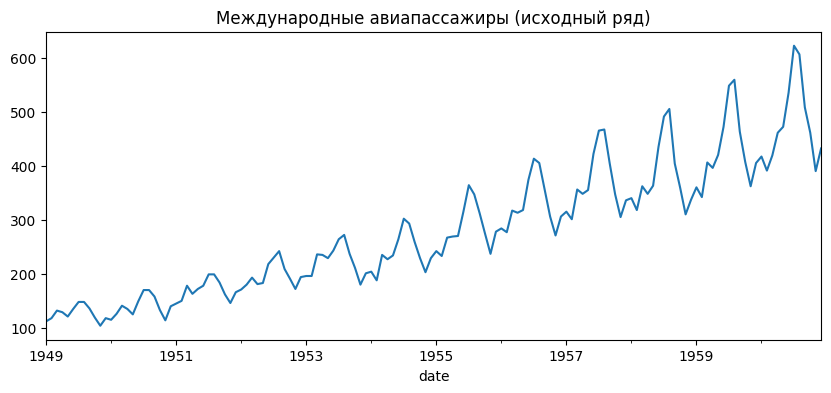

In [7]:
plt.figure(figsize=(10,4))
y.plot()
plt.title('Международные авиапассажиры (исходный ряд)')
plt.show()

Тест ADF на стационарность

In [9]:
result = adfuller(y.dropna())
print('ADF statistic:', result[0])
print('p-value:', result[1])

ADF statistic: 0.8153688792060498
p-value: 0.991880243437641


Дифференцирование (d=1)




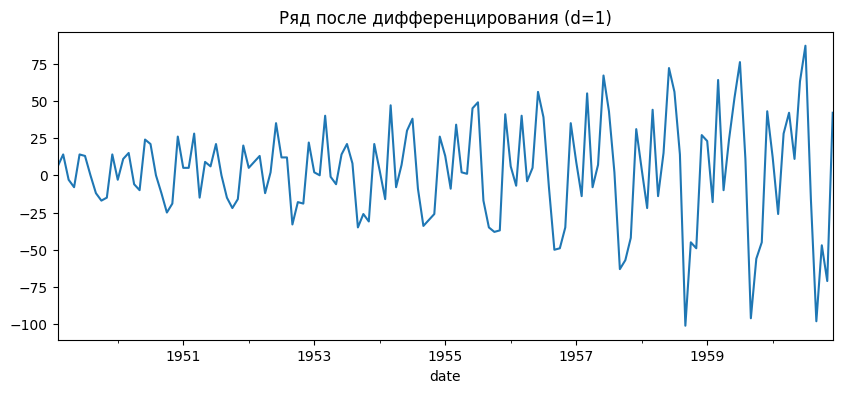

In [10]:
y_diff = y.diff().dropna()

plt.figure(figsize=(10,4))
y_diff.plot()
plt.title('Ряд после дифференцирования (d=1)')
plt.show()

ACF / PACF

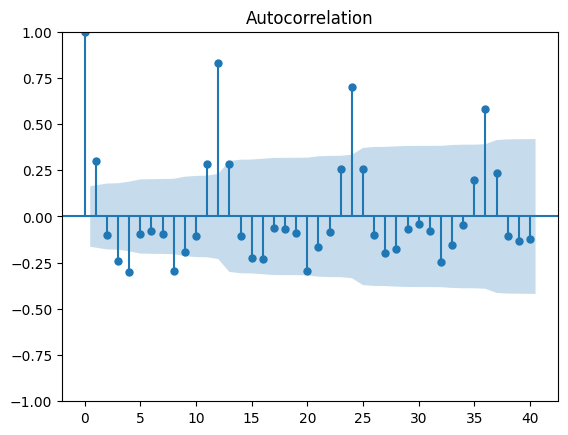

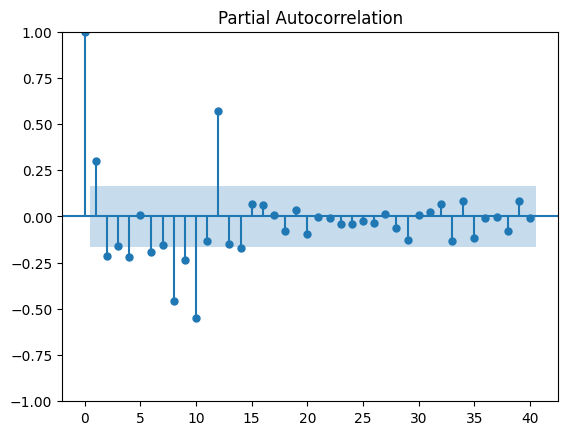

In [11]:
plot_acf(y_diff, lags=40)
plt.show()

plot_pacf(y_diff, lags=40)
plt.show()

Перебор ARIMA(p,1,q) по AIC

In [12]:
p = range(0, 4)
d = [1]
q = range(0, 4)

best_aic = np.inf
best_order = None
best_model = None

for order in itertools.product(p, d, q):
    try:
        model = ARIMA(y, order=order).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_order = order
            best_model = model
    except Exception:
        continue

print("Лучшие параметры ARIMA:", best_order, "AIC:", best_aic)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

Лучшие параметры ARIMA: (3, 1, 3) AIC: 1345.9380392791873


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Предсказание и остатки

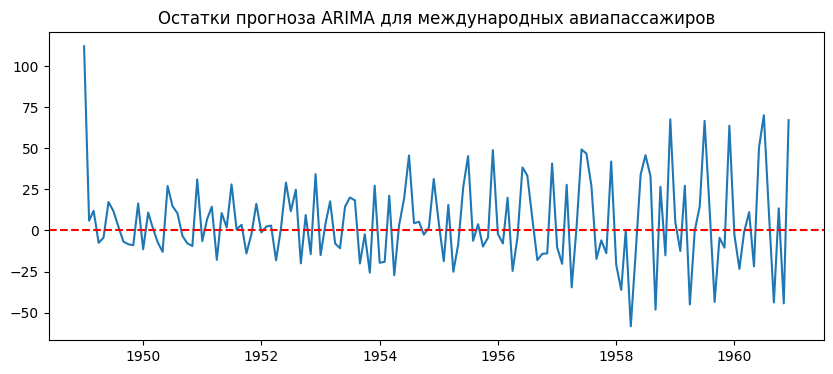

In [13]:
y_pred = best_model.fittedvalues
residuals = y - y_pred

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Остатки прогноза ARIMA для международных авиапассажиров')
plt.show()

ACF остатков

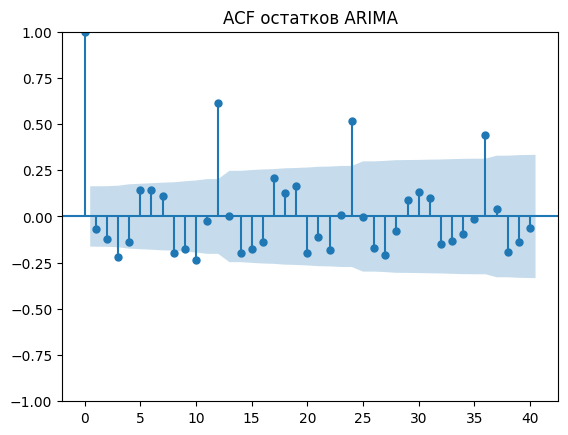

In [14]:
plot_acf(residuals.dropna(), lags=40)
plt.title('ACF остатков ARIMA')
plt.show()

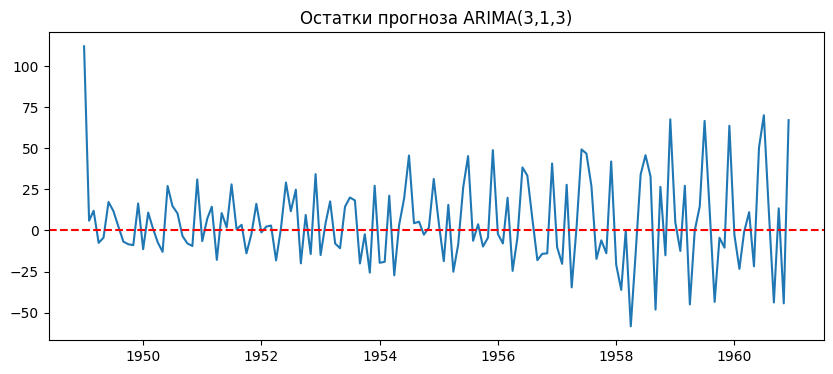

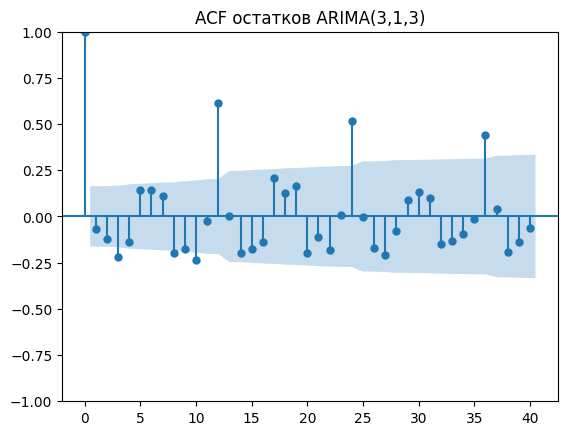

In [15]:
y_pred = best_model.fittedvalues
residuals = y - y_pred

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Остатки прогноза ARIMA(3,1,3)')
plt.show()

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals.dropna(), lags=40)
plt.title('ACF остатков ARIMA(3,1,3)')
plt.show()


Для ряда международных авиапассажиров была построена модель ARIMA с подбором параметров по AIC; оптимальной оказалась ARIMA(3, 1, 3) с AIC ≈ 1345.94. График остатков прогноза показывает, что с кажным годом значения остатков в основном немного увеличиваются, периодически возникают более крупные выбросы. На графике ACF остатков почти все лаги лежат внутри доверительных интервалов, за исключением нескольких  лагов, что говорит об отсутствии существенной автокорреляции и в целом подтверждает, что модель достаточно хорошо описывает структуру временного ряда.